# Topic:
AI-Based Mobile Money Fraud Detection Using Machine Learning

In [34]:
# import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, roc_auc_score)

import warnings
warnings.filterwarnings('ignore')

# Load & Analyze Dataset:

In [35]:
# # Load the dataset
org_df = pd.read_csv("PS_20174392719_1491204439457_log 2.csv")

# # Separate classes
fraud = org_df[org_df["isFraud"] == 1]
non_fraud = org_df[org_df["isFraud"] == 0].sample(n=50000, random_state=42)

# # Combine and shuffle
df_small = pd.concat([fraud, non_fraud]).sample(frac=1, random_state=42)

print(df_small.shape)

df_small.to_csv("credit_card_balanced.csv", index=False)


(58213, 11)


In [36]:
df = pd.read_csv("credit_card_balanced.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,141,PAYMENT,9089.15,C916609715,36375.0,27285.85,M1988694494,0.00,0.00,0,0
1,39,CASH_IN,46702.66,C1196708951,1403541.1,1450243.76,C691837768,3249011.68,3202309.03,0,0
2,103,CASH_OUT,1254092.10,C1741433244,1254092.1,0.00,C663883872,0.00,1254092.10,1,0
3,404,PAYMENT,13511.09,C1225743917,49827.0,36315.91,M798517647,0.00,0.00,0,0
4,308,CASH_OUT,24681.51,C328549376,429568.0,404886.49,C630329198,271223.66,295905.16,0,0


In [37]:
# Check missing values in dataframe
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [38]:
# Check duplicate records in dataframe
df.duplicated().sum()

np.int64(0)

In [39]:
# Information about dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 58213 entries, 0 to 58212
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            58213 non-null  int64  
 1   type            58213 non-null  str    
 2   amount          58213 non-null  float64
 3   nameOrig        58213 non-null  str    
 4   oldbalanceOrg   58213 non-null  float64
 5   newbalanceOrig  58213 non-null  float64
 6   nameDest        58213 non-null  str    
 7   oldbalanceDest  58213 non-null  float64
 8   newbalanceDest  58213 non-null  float64
 9   isFraud         58213 non-null  int64  
 10  isFlaggedFraud  58213 non-null  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 4.9 MB


In [40]:
# Summary statistics for numerical variables
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,58213.000000,5.821300e+04,5.821300e+04,5.821300e+04,5.821300e+04,5.821300e+04,58213.000000,58213.000000
mean,260.937832,3.622564e+05,9.210085e+05,7.348422e+05,1.012553e+06,1.225120e+06,0.141085,0.000275
std,161.216473,1.165412e+06,2.939178e+06,2.747353e+06,3.386217e+06,3.709431e+06,0.348113,0.016577
min,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,157.000000,1.628009e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
50%,253.000000,9.659384e+04,2.263200e+04,0.000000e+00,6.442243e+04,1.894753e+05,0.000000,0.000000
75%,354.000000,2.561716e+05,2.221040e+05,8.910391e+04,8.178433e+05,1.107024e+06,0.000000,0.000000
max,743.000000,6.988673e+07,5.958504e+07,4.958504e+07,2.362305e+08,2.367265e+08,1.000000,1.000000


# EDA(Exploratory Data Analysis):

In [41]:
# Fraud Distribution in Mobile Money Transactions
val_count = df['isFraud'].value_counts()
labels = ['Genuine Transactions' if x == 0 else 'Fraudulent Transactions' for x in val_count.index]

fig = px.pie(
    names=labels,
    values=val_count.values,
    title="Fraud Distribution in Mobile Money Transactions",
    hole=0.45
)

fig.update_layout(
    title_font=dict(size=22, weight="bold"),
    legend_title="Transaction Status",
    width=700,
    height=500
)

fig.show()

In [42]:
# Fraud Occurrence by Transaction Type
fig = px.histogram(
    df,
    x="type",
    color="isFraud",
    barmode="group",
    title="Fraud Occurrence by Transaction Type",
    text_auto=True
)

fig.update_layout(
    title_font=dict(size=22, weight="bold"),
    width=1000,
    height=500
)

fig.show()

In [43]:
# Transaction Volume Over Time, by Fraud Status
fig = px.histogram(
    df,
    x="step",
    color="isFraud",
    nbins=50,
    title="Transaction Volume Over Time (step), by Fraud Status",
    barmode="overlay"
)

fig.update_layout(
    title_font=dict(size=22, weight="bold"),
    width=1000,
    height=500
)

fig.show()

In [44]:
# Transaction Amount Comparison Between Fraud and Genuine Transactions
fig = px.box(
    df,
    x="isFraud",
    y="amount",
    title="Transaction Amount Comparison Between Fraud and Genuine Transactions"
)

fig.update_layout(
    title_font=dict(size=22, weight="bold"),
    width=1000,
    height=500,
    yaxis_type="log"
)

fig.show()

In [45]:
# Sender's Balance Before Transaction, by Fraud Status
fig = px.box(
    df,
    x="isFraud",
    y="oldbalanceOrg",
    title="Sender's Balance Before Transaction, by Fraud Status"
)

fig.update_layout(
    title_font=dict(size=22, weight="bold"),
    width=1000,
    height=500,
    yaxis_type="log"
)

fig.show()

In [46]:
# Sender's Remaining Balance After Transaction, by Fraud Status
fig = px.box(
    df,
    x="isFraud",
    y="newbalanceOrig",
    title="Sender's Remaining Balance After Transaction, by Fraud Status"
)

fig.update_layout(
    title_font=dict(size=22, weight="bold"),
    width=1000,
    height=500,
    yaxis_type= "log"
)

fig.show()

In [47]:
# Recipient's Balance Before Transaction, by Fraud Status
fig = px.box(
    df,
    x="isFraud",
    y="oldbalanceDest",
    title="Recipient's Balance Before Transaction, by Fraud Status"
)

fig.update_layout(
    title_font=dict(size=22, weight="bold"),
    width=1000,
    height=500,
    yaxis_type= "log"
)

fig.show()

In [68]:
# Recipient's Balance After Transaction, by Fraud Status
fig = px.box(
    df,
    x="isFraud",
    y="newbalanceDest",
    title="Recipient's Balance After Transaction, by Fraud Status"
)

fig.update_layout(
    title_font=dict(size=22, weight="bold"),
    width=1000,
    height=500,
    yaxis_type= "log"
)

fig.show()

In [49]:
# isFlaggedFraud vs isFraud Cross-tabulation
pd.crosstab(df['isFlaggedFraud'], df['isFraud'], margins=True)

isFraud,0,1,All
isFlaggedFraud,,,
0,50000,8197,58197
1,0,16,16
All,50000,8213,58213


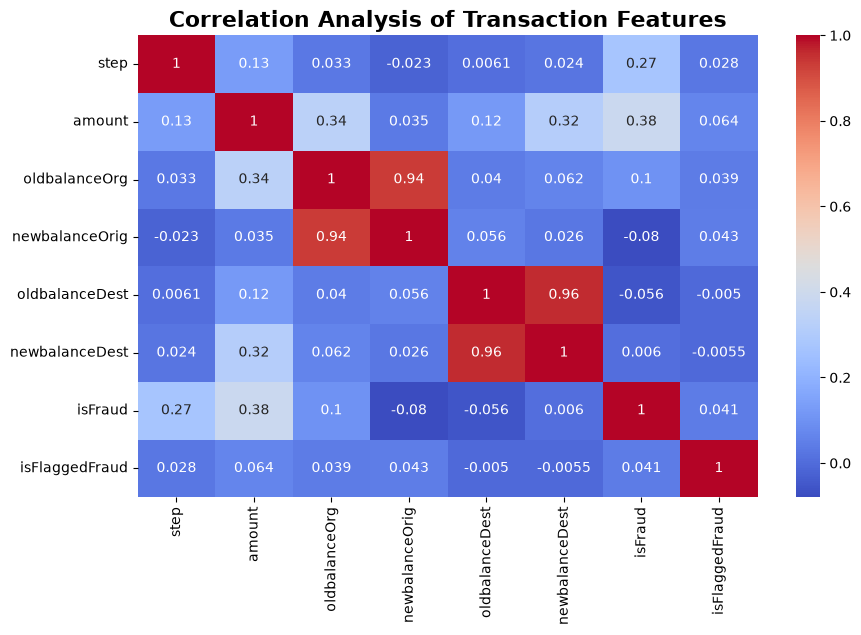

In [50]:
# Correlation Analysis of Transaction Features
plt.figure(figsize=(10, 6))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Analysis of Transaction Features", fontsize=16, fontweight='bold')
plt.show()

# Outlier Detection & Handling

In [51]:
# Count outliers per column using the IQR method
outlier_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f"{col}: {n_outliers} outliers ({n_outliers / len(df) * 100:.1f}% of rows)")

amount: 5436 outliers (9.3% of rows)
oldbalanceOrg: 10234 outliers (17.6% of rows)
newbalanceOrig: 10501 outliers (18.0% of rows)
oldbalanceDest: 7557 outliers (13.0% of rows)
newbalanceDest: 6833 outliers (11.7% of rows)


In [52]:
# Cap extreme values at the 1st and 99th percentiles (winsorization) instead of removing rows
for col in outlier_cols:
    lower_cap = df[col].quantile(0.01)
    upper_cap = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower_cap, upper=upper_cap)

df[outlier_cols].describe()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
count,5.821300e+04,5.821300e+04,5.821300e+04,5.821300e+04,5.821300e+04
mean,3.368148e+05,8.573646e+05,6.727543e+05,9.108264e+05,1.110974e+06
std,9.225529e+05,2.464806e+06,2.279346e+06,1.993289e+06,2.231144e+06
min,4.668280e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.628009e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,9.659384e+04,2.263200e+04,0.000000e+00,6.442243e+04,1.894753e+05
75%,2.561716e+05,2.221040e+05,8.910391e+04,8.178433e+05,1.107024e+06
max,7.044228e+06,1.536042e+07,1.474204e+07,1.187970e+07,1.273874e+07


In [53]:
# Transaction Amount Comparison After Outlier Capping
fig = px.box(
    df,
    x="isFraud",
    y="amount",
    title="Transaction Amount Comparison After Outlier Capping"
)

fig.update_layout(
    title_font=dict(size=22, weight="bold"),
    width=1000,
    height=500,
    yaxis_type="log"
)

fig.show()

# Pre Processing

In [54]:
# Drop unnecessary columns
df = df.drop(['nameOrig', 'nameDest'], axis=1)
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,141,PAYMENT,9089.15,36375.0,27285.85,0.00,0.00,0,0
1,39,CASH_IN,46702.66,1403541.1,1450243.76,3249011.68,3202309.03,0,0
2,103,CASH_OUT,1254092.10,1254092.1,0.00,0.00,1254092.10,1,0
3,404,PAYMENT,13511.09,49827.0,36315.91,0.00,0.00,0,0
4,308,CASH_OUT,24681.51,429568.0,404886.49,271223.66,295905.16,0,0


# Feature Enginnering

In [55]:
df['errorBalanceOrig'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']
df[['oldbalanceOrg', 'amount', 'newbalanceOrig', 'errorBalanceOrig']].head()

,oldbalanceOrg,amount,newbalanceOrig,errorBalanceOrig
0,36375.0,9089.15,27285.85,0.00
1,1403541.1,46702.66,1450243.76,-93405.32
2,1254092.1,1254092.10,0.00,0.00
3,49827.0,13511.09,36315.91,0.00
4,429568.0,24681.51,404886.49,0.00


In [56]:
df['errorBalanceDest'] = df['newbalanceDest'] - df['oldbalanceDest'] - df['amount']
df[['oldbalanceDest', 'amount', 'newbalanceDest', 'errorBalanceDest']].head()

,oldbalanceDest,amount,newbalanceDest,errorBalanceDest
0,0.00,9089.15,0.00,-9089.15
1,3249011.68,46702.66,3202309.03,-93405.31
2,0.00,1254092.10,1254092.10,0.00
3,0.00,13511.09,0.00,-13511.09
4,271223.66,24681.51,295905.16,-0.01


In [57]:
df['hourOfDay'] = df['step'] % 24
df[['step', 'hourOfDay']].head()

,step,hourOfDay
0,141,21
1,39,15
2,103,7
3,404,20
4,308,20


In [58]:
df['origBalanceDepleted'] = ((df['newbalanceOrig'] == 0) & (df['oldbalanceOrg'] > 0)).astype(int)
df[['oldbalanceOrg', 'newbalanceOrig', 'origBalanceDepleted']].head()

,oldbalanceOrg,newbalanceOrig,origBalanceDepleted
0,36375.0,27285.85,0
1,1403541.1,1450243.76,0
2,1254092.1,0.00,1
3,49827.0,36315.91,0
4,429568.0,404886.49,0


In [59]:
# Correlation of the newly engineered features with the fraud label
df[['errorBalanceOrig', 'errorBalanceDest', 'hourOfDay', 'origBalanceDepleted', 'isFraud']].corr()['isFraud']

errorBalanceOrig       0.180069
errorBalanceDest      -0.267959
hourOfDay             -0.266762
origBalanceDepleted    0.540366
isFraud                1.000000
Name: isFraud, dtype: float64

## Checking for data leakage before finalising the feature set

In [60]:
# Check how often this simple, deterministic rule matches isFraud on its own
leak_rule = (
    (df['type'].isin(['CASH_OUT', 'TRANSFER'])) &
    (df['newbalanceOrig'] == 0) &
    (df['amount'] == df['oldbalanceOrg'])
)
pd.crosstab(leak_rule, df['isFraud'])

isFraud,0,1
row_0,,
False,50000,603
True,0,7610


In [61]:
# Drop the two engineered features found to leak the label
df = df.drop(['errorBalanceOrig', 'origBalanceDepleted'], axis=1)
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,errorBalanceDest,hourOfDay
0,141,PAYMENT,9089.15,36375.0,27285.85,0.00,0.00,0,0,-9089.15,21
1,39,CASH_IN,46702.66,1403541.1,1450243.76,3249011.68,3202309.03,0,0,-93405.31,15
2,103,CASH_OUT,1254092.10,1254092.1,0.00,0.00,1254092.10,1,0,0.00,7
3,404,PAYMENT,13511.09,49827.0,36315.91,0.00,0.00,0,0,-13511.09,20
4,308,CASH_OUT,24681.51,429568.0,404886.49,271223.66,295905.16,0,0,-0.01,20


In [62]:
# Apply One-Hot Encoding
df_encoded = pd.get_dummies(
    df,
    columns=['type'],
    drop_first=True
)

# Convert boolean to integer
df_encoded = df_encoded.astype(int)

df_encoded.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,errorBalanceDest,hourOfDay,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,141,9089,36375,27285,0,0,0,0,-9089,21,0,0,1,0
1,39,46702,1403541,1450243,3249011,3202309,0,0,-93405,15,0,0,0,0
2,103,1254092,1254092,0,0,1254092,1,0,0,7,1,0,0,0
3,404,13511,49827,36315,0,0,0,0,-13511,20,0,0,1,0
4,308,24681,429568,404886,271223,295905,0,0,0,20,1,0,0,0


In [63]:
# Apply standard scaler
scaler = StandardScaler()

scaled_features = [
    'step',
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'errorBalanceDest'
]

df_encoded[scaled_features] = scaler.fit_transform(
    df_encoded[scaled_features]
)

df_encoded.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,errorBalanceDest,hourOfDay,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,-0.743962,-0.355240,-0.333088,-0.283184,-0.456950,-0.497943,0,0,0.179924,21,0,0,1,0
1,-1.376657,-0.314470,0.221592,0.341105,1.173038,0.937346,0,0,0.061013,15,0,0,0,0
2,-0.979672,0.994290,0.160958,-0.295155,-0.456950,0.064146,1,0,0.192742,7,1,0,0,0
3,0.887399,-0.350447,-0.327630,-0.279223,-0.456950,-0.497943,0,0,0.173687,20,0,0,1,0
4,0.291922,-0.338339,-0.173563,-0.117521,-0.320881,-0.365317,0,0,0.192742,20,1,0,0,0


In [64]:
# Separate features and target variable
X = df_encoded.drop('isFraud', axis=1)
y = df_encoded['isFraud']

# Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check shape
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (46570, 13)
Testing Data: (11643, 13)


# Machine Learning Models

Logistic Regression Performance

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     10000
           1       0.97      0.80      0.88      1643

    accuracy                           0.97     11643
   macro avg       0.97      0.90      0.93     11643
weighted avg       0.97      0.97      0.97     11643



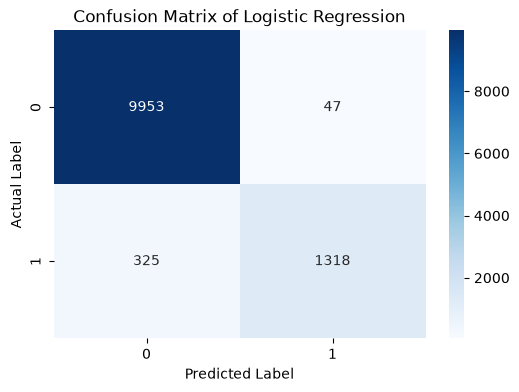

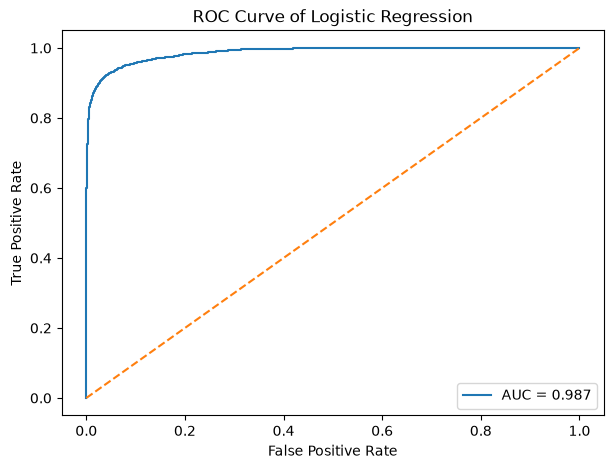

In [65]:
# Train Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train, y_train)

# Prediction
lr_pred = lr_model.predict(X_test)

# Probability for ROC curve
lr_prob = lr_model.predict_proba(X_test)[:, 1]

# Classification Report
print("Logistic Regression Performance")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix of Logistic Regression")
plt.show()

# ROC Curve
auc = roc_auc_score(y_test, lr_prob)
fpr, tpr, thresholds = roc_curve(y_test, lr_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of Logistic Regression")
plt.legend()
plt.show()

Decision Tree Performance

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10000
           1       0.97      0.98      0.98      1643

    accuracy                           0.99     11643
   macro avg       0.99      0.99      0.99     11643
weighted avg       0.99      0.99      0.99     11643



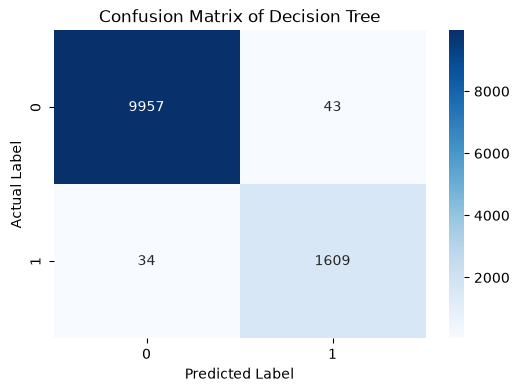

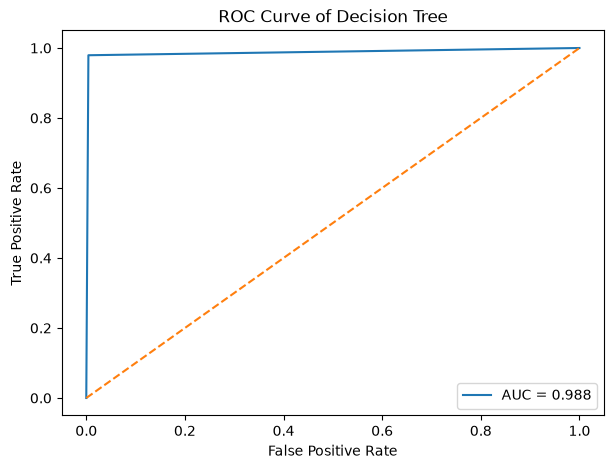

In [66]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Prediction
dt_pred = dt_model.predict(X_test)

# Probability for ROC curve
dt_prob = dt_model.predict_proba(X_test)[:, 1]

# Classification Report
print("Decision Tree Performance")
print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, dt_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix of Decision Tree")
plt.show()

# ROC Curve
auc = roc_auc_score(y_test, dt_prob)
fpr, tpr, thresholds = roc_curve(y_test, dt_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of Decision Tree")
plt.legend()
plt.show()

Random Forest Performance

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10000
           1       0.98      0.97      0.98      1643

    accuracy                           0.99     11643
   macro avg       0.99      0.98      0.99     11643
weighted avg       0.99      0.99      0.99     11643



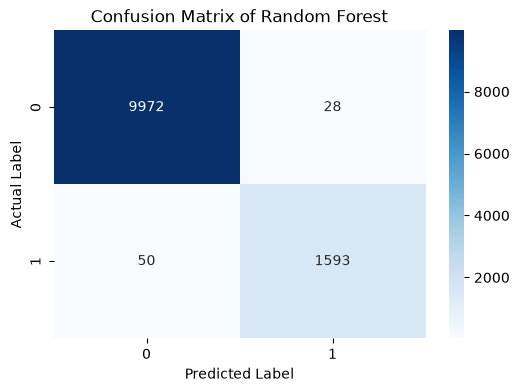

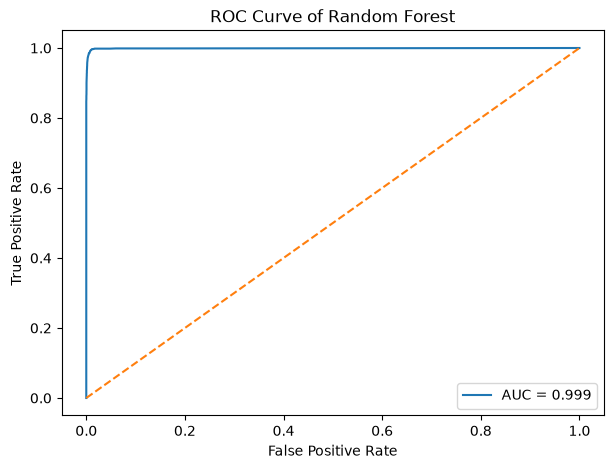

In [67]:
# Train Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Prediction
rf_pred = rf_model.predict(X_test)

# Probability for ROC curve
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Classification Report
print("Random Forest Performance")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix of Random Forest")
plt.show()

# ROC Curve
auc = roc_auc_score(y_test, rf_prob)
fpr, tpr, thresholds = roc_curve(y_test, rf_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of Random Forest")
plt.legend()
plt.show()